# 常见坐标系下的面积元、体积元与 Jacobian

本笔记讨论以下常见坐标系：

1. 二维直角坐标；
2. 二维极坐标；
3. 三维直角坐标；
4. 三维圆柱坐标；
5. 三维球坐标。

内容分为三部分：

1. **几何方式推导**：利用微小边长、扇形、圆弧长度等几何关系推导微元；
2. **Jacobian 方式推导**：从局部线性映射、行列式和面积/体积伸缩的角度推导；
3. **Matplotlib 可视化**：绘制坐标网格、微小面积元、三维体积元和坐标曲面面积元。

---

## 术语说明

在二维空间中，两个独立坐标微分围成的是**面积元**：

$$
dA.
$$

在三维空间中，三个独立坐标微分围成的是**体积元**：

$$
dV.
$$

如果在三维空间中固定一个坐标，只让另外两个坐标变化，则得到一个坐标曲面，其上的微元是**曲面面积元**：

$$
dS.
$$

因此，本笔记会同时总结：

- 二维面积元 $dA$；
- 三维体积元 $dV$；
- 三维坐标曲面上的面积元 $dS$。

---

## 坐标约定

### 二维极坐标

$$
x=r\cos\theta,\qquad y=r\sin\theta,
$$

其中

$$
r\geq 0,\qquad 0\leq\theta<2\pi.
$$

### 三维圆柱坐标

$$
x=r\cos\theta,\qquad
y=r\sin\theta,\qquad
z=z.
$$

### 三维球坐标

本笔记采用数学和物理中常见的约定：

$$
x=\rho\sin\varphi\cos\theta,
$$

$$
y=\rho\sin\varphi\sin\theta,
$$

$$
z=\rho\cos\varphi.
$$

其中：

- $\rho\geq0$：到原点的距离；
- $0\leq\varphi\leq\pi$：从 $z$ 轴正方向量起的极角；
- $0\leq\theta<2\pi$：绕 $z$ 轴的方位角。

注意：部分教材会交换 $\theta$ 与 $\varphi$ 的含义，使用公式时应先检查符号约定。

## 最终公式预览

### 二维面积元

| 坐标系 | 坐标变换 | 面积元 |
|---|---|---|
| 直角坐标 | $x=x,\ y=y$ | $\boxed{dA=dx\,dy}$ |
| 极坐标 | $x=r\cos\theta,\ y=r\sin\theta$ | $\boxed{dA=r\,dr\,d\theta}$ |

### 三维体积元

| 坐标系 | 体积元 |
|---|---|
| 直角坐标 | $\boxed{dV=dx\,dy\,dz}$ |
| 圆柱坐标 | $\boxed{dV=r\,dr\,d\theta\,dz}$ |
| 球坐标 | $\boxed{dV=\rho^2\sin\varphi\,d\rho\,d\varphi\,d\theta}$ |

### 三维坐标曲面面积元

#### 直角坐标

$$
x=\text{常数}:\quad dS=dy\,dz,
$$

$$
y=\text{常数}:\quad dS=dx\,dz,
$$

$$
z=\text{常数}:\quad dS=dx\,dy.
$$

#### 圆柱坐标

$$
r=\text{常数}:\quad dS=r\,d\theta\,dz,
$$

$$
\theta=\text{常数}:\quad dS=dr\,dz,
$$

$$
z=\text{常数}:\quad dS=r\,dr\,d\theta.
$$

#### 球坐标

$$
\rho=\text{常数}:\quad
dS=\rho^2\sin\varphi\,d\varphi\,d\theta,
$$

$$
\varphi=\text{常数}:\quad
dS=\rho\sin\varphi\,d\rho\,d\theta,
$$

$$
\theta=\text{常数}:\quad
dS=\rho\,d\rho\,d\varphi.
$$

In [4]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from matplotlib.patches import Rectangle, Wedge, Polygon
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 尝试使用常见中文字体；如果系统未安装，Matplotlib 会自动回退
plt.rcParams["font.sans-serif"] = [
    "Noto Sans CJK SC",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = False

print("NumPy version:", np.__version__)
print("SymPy version:", sp.__version__)

NumPy version: 2.4.6
SymPy version: 1.14.0


# 1. 几何方式推导

## 1.1 二维直角坐标的面积元

在直角坐标系中，考虑一个微小矩形：

- 水平方向边长为 $dx$；
- 竖直方向边长为 $dy$。

因此面积为

$$
dA=dx\,dy.
$$

即

$$
\boxed{dA=dx\,dy}.
$$

直角坐标的两个坐标方向互相垂直，并且坐标增量与实际长度相等，所以不需要额外的伸缩因子。

---

## 1.2 二维极坐标的面积元

极坐标变换为

$$
x=r\cos\theta,\qquad y=r\sin\theta.
$$

考虑由以下边界围成的一个微小环形扇区：

$$
r\leq \widetilde r\leq r+dr,
$$

$$
\theta\leq\widetilde\theta\leq\theta+d\theta.
$$

它的两个主要方向边长为：

### 径向边长

当 $\theta$ 固定、$r$ 增加 $dr$ 时，实际长度为

$$
dl_r=dr.
$$

### 角向边长

当 $r$ 固定、角度增加 $d\theta$ 时，沿半径为 $r$ 的圆弧运动。

圆弧长度为

$$
dl_\theta=r\,d\theta.
$$

因此微小扇区可以在一阶近似下看成边长分别为

$$
dr,\qquad r\,d\theta
$$

的矩形，于是

$$
dA=(dr)(r\,d\theta).
$$

所以

$$
\boxed{dA=r\,dr\,d\theta}.
$$

---

### 有限小扇区的精确面积

有限环形扇区的精确面积为

$$
\Delta A
=
\frac12\left[(r+\Delta r)^2-r^2\right]\Delta\theta.
$$

展开可得

$$
\Delta A
=
r\,\Delta r\,\Delta\theta
+
\frac12(\Delta r)^2\Delta\theta.
$$

其中一阶主导项是

$$
r\,\Delta r\,\Delta\theta.
$$

当取微分极限时，高阶项被忽略，因此

$$
dA=r\,dr\,d\theta.
$$

这里需要区分：

- 对有限大小的扇区，$r\Delta r\Delta\theta$ 是一阶近似；
- 在变量替换积分中，$r\,dr\,d\theta$ 是由 Jacobian 给出的精确积分测度。

## 1.3 三维直角坐标的体积元

三维直角坐标中的微小长方体具有三条相互垂直的边：

$$
dx,\qquad dy,\qquad dz.
$$

因此体积为

$$
\boxed{dV=dx\,dy\,dz}.
$$

如果固定一个坐标，就得到相应坐标平面上的面积元：

$$
x=\text{常数}:\quad dS=dy\,dz,
$$

$$
y=\text{常数}:\quad dS=dx\,dz,
$$

$$
z=\text{常数}:\quad dS=dx\,dy.
$$

---

## 1.4 三维圆柱坐标的体积元

圆柱坐标为

$$
x=r\cos\theta,\qquad
y=r\sin\theta,\qquad
z=z.
$$

微小圆柱坐标体元有三个局部边长：

1. 径向：

$$
dl_r=dr;
$$

2. 角向：

$$
dl_\theta=r\,d\theta;
$$

3. 竖直方向：

$$
dl_z=dz.
$$

三个方向相互正交，因此体积元为

$$
dV=dl_r\,dl_\theta\,dl_z.
$$

所以

$$
\boxed{dV=r\,dr\,d\theta\,dz}.
$$

### 圆柱坐标的坐标曲面面积元

固定一个坐标，只将另外两个局部边长相乘。

#### 圆柱面 $r=\text{常数}$

两个切向边长为

$$
r\,d\theta,\qquad dz.
$$

所以

$$
\boxed{dS_{r=\text{const}}=r\,d\theta\,dz}.
$$

#### 半平面 $\theta=\text{常数}$

两个切向边长为

$$
dr,\qquad dz.
$$

所以

$$
\boxed{dS_{\theta=\text{const}}=dr\,dz}.
$$

#### 水平面 $z=\text{常数}$

两个切向边长为

$$
dr,\qquad r\,d\theta.
$$

所以

$$
\boxed{dS_{z=\text{const}}=r\,dr\,d\theta}.
$$

## 1.5 三维球坐标的体积元

球坐标变换为

$$
x=\rho\sin\varphi\cos\theta,
$$

$$
y=\rho\sin\varphi\sin\theta,
$$

$$
z=\rho\cos\varphi.
$$

考虑一个微小球坐标体元。

### 径向边长

固定 $\varphi,\theta$，只改变 $\rho$：

$$
dl_\rho=d\rho.
$$

### 极角方向边长

固定 $\rho,\theta$，改变极角 $\varphi$。

这时点沿半径为 $\rho$ 的经线圆运动，因此弧长为

$$
dl_\varphi=\rho\,d\varphi.
$$

### 方位角方向边长

固定 $\rho,\varphi$，改变方位角 $\theta$。

点所在纬线圆的半径不是 $\rho$，而是点到 $z$ 轴的距离：

$$
\rho\sin\varphi.
$$

因此纬线方向的弧长为

$$
dl_\theta=\rho\sin\varphi\,d\theta.
$$

三个局部方向相互正交，所以

$$
dV=dl_\rho\,dl_\varphi\,dl_\theta.
$$

于是

$$
dV
=
d\rho
\left(\rho\,d\varphi\right)
\left(\rho\sin\varphi\,d\theta\right).
$$

因此

$$
\boxed{
dV=\rho^2\sin\varphi\,d\rho\,d\varphi\,d\theta
}.
$$

---

## 1.6 球坐标的坐标曲面面积元

### 球面 $\rho=\text{常数}$

球面上的两个切向边长为

$$
\rho\,d\varphi,
\qquad
\rho\sin\varphi\,d\theta.
$$

所以

$$
\boxed{
dS_{\rho=\text{const}}
=
\rho^2\sin\varphi\,d\varphi\,d\theta
}.
$$

### 圆锥面 $\varphi=\text{常数}$

两个切向边长为

$$
d\rho,
\qquad
\rho\sin\varphi\,d\theta.
$$

所以

$$
\boxed{
dS_{\varphi=\text{const}}
=
\rho\sin\varphi\,d\rho\,d\theta
}.
$$

### 半平面 $\theta=\text{常数}$

两个切向边长为

$$
d\rho,
\qquad
\rho\,d\varphi.
$$

所以

$$
\boxed{
dS_{\theta=\text{const}}
=
\rho\,d\rho\,d\varphi
}.
$$

---

## 1.7 正交曲线坐标的统一写法

设三个正交曲线坐标为

$$
(q_1,q_2,q_3),
$$

对应的局部长度伸缩因子为

$$
h_1,\qquad h_2,\qquad h_3.
$$

即三个局部边长分别为

$$
h_1dq_1,\qquad h_2dq_2,\qquad h_3dq_3.
$$

那么体积元统一写成

$$
\boxed{
dV=h_1h_2h_3\,dq_1\,dq_2\,dq_3
}.
$$

固定 $q_i$ 后，坐标曲面的面积元就是另外两个局部边长的乘积。例如

$$
q_1=\text{常数}
\quad\Longrightarrow\quad
\boxed{
dS=h_2h_3\,dq_2\,dq_3
}.
$$

常见坐标系的尺度因子如下。

| 坐标系 | 坐标次序 | 尺度因子 |
|---|---|---|
| 直角坐标 | $(x,y,z)$ | $(1,1,1)$ |
| 圆柱坐标 | $(r,\theta,z)$ | $(1,r,1)$ |
| 球坐标 | $(\rho,\varphi,\theta)$ | $(1,\rho,\rho\sin\varphi)$ |

# 2. Jacobian 方式推导：局部线性映射

## 2.1 二维变量变换

设坐标变换为

$$
\mathbf F(u,v)
=
\begin{pmatrix}
x(u,v)\\
y(u,v)
\end{pmatrix}.
$$

在点 $(u,v)$ 附近，对一个小增量

$$
d\mathbf q=
\begin{pmatrix}
du\\
dv
\end{pmatrix},
$$

一阶 Taylor 展开给出

$$
\mathbf F(\mathbf q+d\mathbf q)
\approx
\mathbf F(\mathbf q)+J\,d\mathbf q,
$$

其中

$$
J
=
\frac{\partial(x,y)}{\partial(u,v)}
=
\begin{pmatrix}
\dfrac{\partial x}{\partial u}
&
\dfrac{\partial x}{\partial v}
\$$6pt]
\dfrac{\partial y}{\partial u}
&
\dfrac{\partial y}{\partial v}
\end{pmatrix}.
$$

也就是说，非线性坐标变换在足够小的邻域内近似为线性变换 $J$。

参数平面中的小矩形由向量

$$
\begin{pmatrix}du\\0\end{pmatrix},
\qquad
\begin{pmatrix}0\\dv\end{pmatrix}
$$

张成。

经过 Jacobian 线性映射后，它们分别变成

$$
\frac{\partial\mathbf F}{\partial u}du,
\qquad
\frac{\partial\mathbf F}{\partial v}dv.
$$

这两个向量张成一个平行四边形，其面积为

$$
\left|\det J\right|du\,dv.
$$

因此二维变量替换公式为

$$
\boxed{
dA=
\left|
\frac{\partial(x,y)}{\partial(u,v)}
\right|
du\,dv
}.
$$

行列式的绝对值表示局部面积伸缩倍数；行列式的正负号表示定向是否发生翻转。

---

## 2.2 极坐标的 Jacobian

极坐标变换为

$$
x=r\cos\theta,\qquad
y=r\sin\theta.
$$

Jacobian 矩阵为

$$
J_{\text{polar}}
=
\frac{\partial(x,y)}{\partial(r,\theta)}
=
\begin{pmatrix}
\cos\theta & -r\sin\theta\\
\sin\theta & r\cos\theta
\end{pmatrix}.
$$

其行列式为

$$
\det J_{\text{polar}}
=
r\cos^2\theta+r\sin^2\theta
=
r.
$$

所以

$$
\boxed{
dA=r\,dr\,d\theta
}.
$$

Jacobian 的两列分别是

$$
\frac{\partial\mathbf F}{\partial r}
=
\begin{pmatrix}
\cos\theta\\
\sin\theta
\end{pmatrix},
$$

$$
\frac{\partial\mathbf F}{\partial\theta}
=
\begin{pmatrix}
-r\sin\theta\\
r\cos\theta
\end{pmatrix}.
$$

它们的长度分别为

$$
1,\qquad r,
$$

并且互相垂直。这正好对应几何推导中的局部边长

$$
dr,\qquad r\,d\theta.
$$

## 2.3 三维变量变换

设

$$
\mathbf F(q_1,q_2,q_3)
=
\begin{pmatrix}
x(q_1,q_2,q_3)\\
y(q_1,q_2,q_3)\\
z(q_1,q_2,q_3)
\end{pmatrix}.
$$

Jacobian 矩阵为

$$
J
=
\frac{\partial(x,y,z)}
{\partial(q_1,q_2,q_3)}.
$$

局部参数小长方体经过线性映射 $J$ 后变成平行六面体。

线性代数中，三阶行列式的绝对值给出体积伸缩倍数。因此

$$
\boxed{
dV=
\left|
\det
\frac{\partial(x,y,z)}
{\partial(q_1,q_2,q_3)}
\right|
dq_1\,dq_2\,dq_3
}.
$$

---

## 2.4 圆柱坐标的 Jacobian

圆柱坐标变换为

$$
\mathbf F(r,\theta,z)
=
\begin{pmatrix}
r\cos\theta\\
r\sin\theta\\
z
\end{pmatrix}.
$$

Jacobian 矩阵为

$$
J_{\text{cyl}}
=
\begin{pmatrix}
\cos\theta & -r\sin\theta & 0\\
\sin\theta & r\cos\theta & 0\\
0 & 0 & 1
\end{pmatrix}.
$$

其行列式为

$$
\det J_{\text{cyl}}=r.
$$

因此

$$
\boxed{
dV=r\,dr\,d\theta\,dz
}.
$$

---

## 2.5 球坐标的 Jacobian

按照坐标顺序

$$
(\rho,\varphi,\theta),
$$

球坐标变换为

$$
\mathbf F(\rho,\varphi,\theta)
=
\begin{pmatrix}
\rho\sin\varphi\cos\theta\\
\rho\sin\varphi\sin\theta\\
\rho\cos\varphi
\end{pmatrix}.
$$

其三个偏导向量分别为

$$
\frac{\partial\mathbf F}{\partial\rho},
\qquad
\frac{\partial\mathbf F}{\partial\varphi},
\qquad
\frac{\partial\mathbf F}{\partial\theta}.
$$

它们的长度分别为

$$
1,\qquad
\rho,\qquad
\rho\sin\varphi,
$$

并且彼此正交。因此 Jacobian 行列式的绝对值为

$$
\left|\det J_{\text{sph}}\right|
=
1\cdot\rho\cdot\rho\sin\varphi
=
\rho^2\sin\varphi.
$$

所以

$$
\boxed{
dV=
\rho^2\sin\varphi
\,d\rho\,d\varphi\,d\theta
}.
$$

---

## 2.6 三维曲面面积元：$3\times2$ Jacobian

三维空间中的参数曲面写成

$$
\mathbf S(u,v)
=
\begin{pmatrix}
x(u,v)\\
y(u,v)\\
z(u,v)
\end{pmatrix}.
$$

其微分矩阵是一个 $3\times2$ 矩阵：

$$
D\mathbf S
=
\begin{pmatrix}
x_u & x_v\\
y_u & y_v\\
z_u & z_v
\end{pmatrix}.
$$

由于它不是方阵，不能直接计算普通行列式。

局部参数小矩形的两条边经过线性映射后变成

$$
\mathbf S_u\,du,
\qquad
\mathbf S_v\,dv.
$$

它们张成的平行四边形面积为

$$
\|\mathbf S_u\times\mathbf S_v\|\,du\,dv.
$$

因此曲面面积元为

$$
\boxed{
dS=
\|\mathbf S_u\times\mathbf S_v\|\,du\,dv
}.
$$

等价地，可以使用 Gram 行列式：

$$
\boxed{
dS=
\sqrt{
\det\left[
(D\mathbf S)^T(D\mathbf S)
\right]
}
\,du\,dv
}.
$$

这是二维 Jacobian 面积缩放公式在三维曲面中的推广。

例如半径为 $R$ 的球面参数化为

$$
\mathbf S(\varphi,\theta)
=
\begin{pmatrix}
R\sin\varphi\cos\theta\\
R\sin\varphi\sin\theta\\
R\cos\varphi
\end{pmatrix}.
$$

计算可得

$$
\|\mathbf S_\varphi\times\mathbf S_\theta\|
=
R^2\sin\varphi.
$$

因此

$$
\boxed{
dS=R^2\sin\varphi\,d\varphi\,d\theta
}.
$$

## 2.7 使用 SymPy 验证 Jacobian

下面通过符号计算验证：

- 极坐标二维 Jacobian；
- 圆柱坐标三维 Jacobian；
- 球坐标三维 Jacobian；
- 球面参数化的曲面面积因子。

In [11]:
# 定义符号
r, theta, z = sp.symbols("r theta z", positive=True, real=True)
rho, phi = sp.symbols("rho phi", positive=True, real=True)
R = sp.symbols("R", positive=True, real=True)

# ------------------------------------------------------------
# 1. 二维极坐标
# ------------------------------------------------------------
F_polar = sp.Matrix([
    r * sp.cos(theta),
    r * sp.sin(theta),
])

J_polar = F_polar.jacobian([r, theta])
det_polar = sp.simplify(J_polar.det())

display(Markdown("### 二维极坐标"))
display(Markdown(r"$$\nJ_{\mathrm{polar}}=\n$$"))
display(J_polar)
display(Markdown(r"$$\n\det J_{\mathrm{polar}}=\n$$"))
display(det_polar)

# ------------------------------------------------------------
# 2. 三维圆柱坐标
# ------------------------------------------------------------
F_cyl = sp.Matrix([
    r * sp.cos(theta),
    r * sp.sin(theta),
    z,
])

J_cyl = F_cyl.jacobian([r, theta, z])
det_cyl = sp.simplify(J_cyl.det())

display(Markdown("### 三维圆柱坐标"))
display(Markdown(r"$$\nJ_{\mathrm{cyl}}=\n$$"))
display(J_cyl)
display(Markdown(r"$$\n\det J_{\mathrm{cyl}}=\n$$"))
display(det_cyl)

# ------------------------------------------------------------
# 3. 三维球坐标
# 坐标顺序为 (rho, phi, theta)
# ------------------------------------------------------------
F_sph = sp.Matrix([
    rho * sp.sin(phi) * sp.cos(theta),
    rho * sp.sin(phi) * sp.sin(theta),
    rho * sp.cos(phi),
])

J_sph = F_sph.jacobian([rho, phi, theta])
det_sph = sp.trigsimp(sp.simplify(J_sph.det()))

display(Markdown("### 三维球坐标"))
display(Markdown(r"$$\nJ_{\mathrm{sph}}=\n$$"))
display(J_sph)
display(Markdown(r"$$\n\det J_{\mathrm{sph}}=\n$$"))
display(det_sph)
display(Markdown(
    r"在 $0\leq\varphi\leq\pi$ 内，$\sin\varphi\geq0$，"
    r"所以体积伸缩因子为 $\rho^2\sin\varphi$。"
))

# ------------------------------------------------------------
# 4. 球面面积元
# ------------------------------------------------------------
S_sphere = sp.Matrix([
    R * sp.sin(phi) * sp.cos(theta),
    R * sp.sin(phi) * sp.sin(theta),
    R * sp.cos(phi),
])

S_phi = S_sphere.diff(phi)
S_theta = S_sphere.diff(theta)

cross_product = sp.simplify(S_phi.cross(S_theta))
surface_factor_squared = sp.trigsimp(
    sp.simplify(cross_product.dot(cross_product))
)

display(Markdown(r"### 半径为 $R$ 的球面"))
display(Markdown(r"$$\n\mathbf S_\varphi=\n$$"))
display(S_phi)
display(Markdown(r"$$\n\mathbf S_\theta=\n$$"))
display(S_theta)
display(Markdown(r"$$\n\mathbf S_\varphi\times\mathbf S_\theta=\n$$"))
display(cross_product)
display(Markdown(r"$$\n\|\mathbf S_\varphi\times\mathbf S_\theta\|^2=\n$$"))
display(surface_factor_squared)
display(Markdown(
    r"因此在 $0\leq\varphi\leq\pi$ 内，"
    r"$\|\mathbf S_\varphi\times\mathbf S_\theta\|"
    r"=R^2\sin\varphi$。"
))

### 二维极坐标

$$\nJ_{\mathrm{polar}}=\n$$

Matrix([
[cos(theta), -r*sin(theta)],
[sin(theta),  r*cos(theta)]])

$$\n\det J_{\mathrm{polar}}=\n$$

r

...

$$\n\mathbf S_\varphi\times\mathbf S_\theta=\n$$

Matrix([
[R**2*sin(phi)**2*cos(theta)],
[R**2*sin(phi)**2*sin(theta)],
[          R**2*sin(2*phi)/2]])

$$\n\|\mathbf S_\varphi\times\mathbf S_\theta\|^2=\n$$

R**4*sin(phi)**2

因此在 $0\leq\varphi\leq\pi$ 内，$\|\mathbf S_\varphi\times\mathbf S_\theta\|=R^2\sin\varphi$。

# 3. Matplotlib 可视化

下面分别绘制：

1. 二维直角坐标与极坐标网格；
2. 二维面积元；
3. 极坐标 Jacobian 的局部线性映射；
4. 三维直角、圆柱、球坐标体元；
5. 圆柱面和球面上的面积元。

## 3.1 二维直角坐标与极坐标面积元

左图中，直角坐标的微小矩形面积为

$$
dA=dx\,dy.
$$

右图中，极坐标的微小环形扇区具有局部边长

$$
dr,\qquad r\,d\theta,
$$

因此

$$
dA=r\,dr\,d\theta.
$$

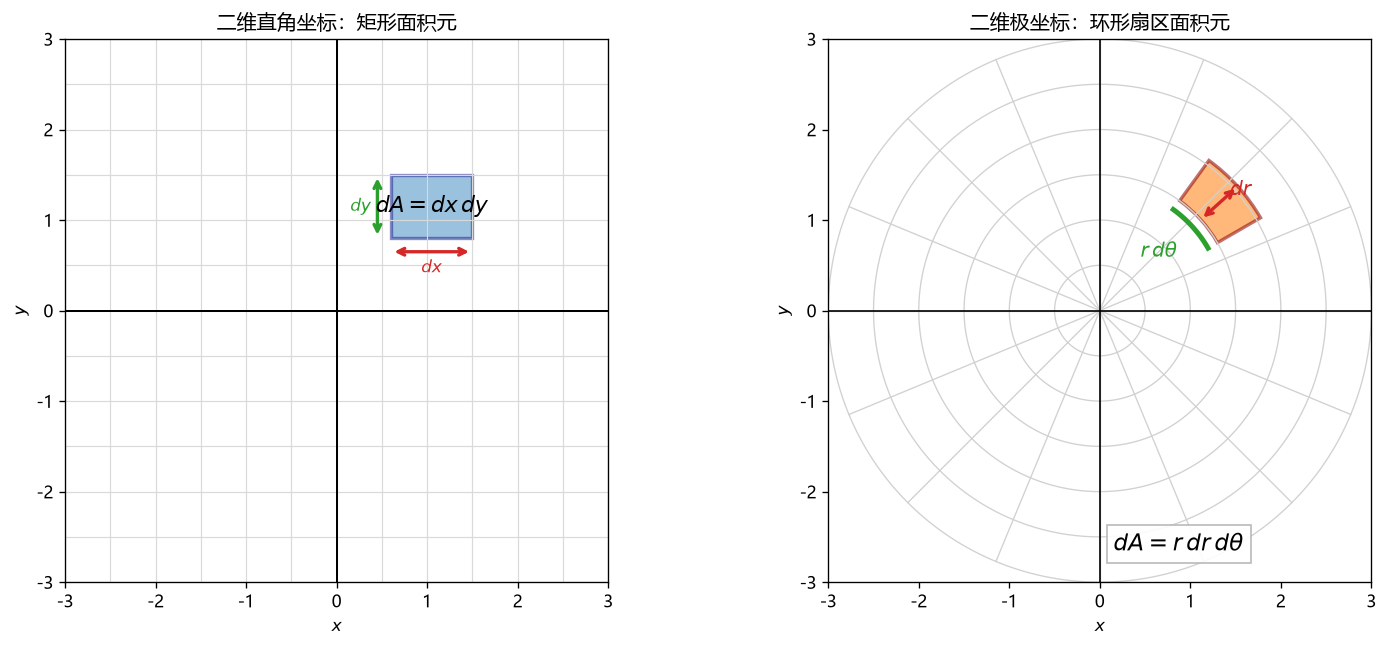

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ============================================================
# 左图：二维直角坐标
# ============================================================
ax = axes[0]

grid_values = np.arange(-3, 3.1, 0.5)

for value in grid_values:
    ax.plot([-3, 3], [value, value], color="0.85", lw=0.7)
    ax.plot([value, value], [-3, 3], color="0.85", lw=0.7)

ax.axhline(0, color="black", lw=1.2)
ax.axvline(0, color="black", lw=1.2)

x0, y0 = 0.6, 0.8
dx, dy = 0.9, 0.7

rect = Rectangle(
    (x0, y0),
    dx,
    dy,
    facecolor="tab:blue",
    edgecolor="navy",
    alpha=0.45,
    linewidth=2,
)
ax.add_patch(rect)

ax.annotate(
    "",
    xy=(x0 + dx, y0 - 0.15),
    xytext=(x0, y0 - 0.15),
    arrowprops={"arrowstyle": "<->", "color": "tab:red", "lw": 2},
)
ax.text(x0 + dx / 2, y0 - 0.38, r"$dx$", ha="center", color="tab:red")

ax.annotate(
    "",
    xy=(x0 - 0.15, y0 + dy),
    xytext=(x0 - 0.15, y0),
    arrowprops={"arrowstyle": "<->", "color": "tab:green", "lw": 2},
)
ax.text(x0 - 0.45, y0 + dy / 2, r"$dy$", va="center", color="tab:green")

ax.text(
    x0 + dx / 2,
    y0 + dy / 2,
    r"$dA=dx\,dy$",
    ha="center",
    va="center",
    fontsize=13,
)

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title("二维直角坐标：矩形面积元")

# ============================================================
# 右图：二维极坐标
# ============================================================
ax = axes[1]

angle_values = np.linspace(0, 2 * np.pi, 500)

# 同心圆
for radius in np.arange(0.5, 3.1, 0.5):
    ax.plot(
        radius * np.cos(angle_values),
        radius * np.sin(angle_values),
        color="0.82",
        lw=0.8,
    )

# 射线
for angle in np.linspace(0, 2 * np.pi, 16, endpoint=False):
    ax.plot(
        [0, 3 * np.cos(angle)],
        [0, 3 * np.sin(angle)],
        color="0.82",
        lw=0.8,
    )

ax.axhline(0, color="black", lw=1)
ax.axvline(0, color="black", lw=1)

r0 = 1.5
dr = 0.55
theta0 = np.deg2rad(30)
dtheta = np.deg2rad(24)

wedge = Wedge(
    center=(0, 0),
    r=r0 + dr,
    theta1=np.rad2deg(theta0),
    theta2=np.rad2deg(theta0 + dtheta),
    width=dr,
    facecolor="tab:orange",
    edgecolor="darkred",
    alpha=0.55,
    linewidth=2,
)
ax.add_patch(wedge)

# 标出径向增量 dr
theta_mid = theta0 + dtheta / 2
p_inner = np.array([
    r0 * np.cos(theta_mid),
    r0 * np.sin(theta_mid),
])
p_outer = np.array([
    (r0 + dr) * np.cos(theta_mid),
    (r0 + dr) * np.sin(theta_mid),
])

ax.annotate(
    "",
    xy=p_outer,
    xytext=p_inner,
    arrowprops={"arrowstyle": "<->", "color": "tab:red", "lw": 2},
)

text_pos = (p_inner + p_outer) / 2 + np.array([0.12, 0.08])
ax.text(text_pos[0], text_pos[1], r"$dr$", color="tab:red", fontsize=12)

# 标出近似角向弧长 r dtheta
arc_t = np.linspace(theta0, theta0 + dtheta, 100)
arc_radius = r0 - 0.12

ax.plot(
    arc_radius * np.cos(arc_t),
    arc_radius * np.sin(arc_t),
    color="tab:green",
    lw=3,
)

arc_mid = theta0 + dtheta / 2
ax.text(
    (arc_radius - 0.5) * np.cos(arc_mid),
    (arc_radius - 0.5) * np.sin(arc_mid),
    r"$r\,d\theta$",
    color="tab:green",
    fontsize=12,
    ha="center",
)

ax.text(
    0.15,
    -2.65,
    r"$dA=r\,dr\,d\theta$",
    fontsize=14,
    bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "0.7"},
)

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title("二维极坐标：环形扇区面积元")

plt.tight_layout()
plt.show()

## 3.2 极坐标 Jacobian 的局部线性映射

极坐标变换

$$
\mathbf F(r,\theta)
=
\begin{pmatrix}
r\cos\theta\\
r\sin\theta
\end{pmatrix}
$$

会把参数平面中的小矩形

$$
[r_0,r_0+\Delta r]
\times
[\theta_0,\theta_0+\Delta\theta]
$$

映射成一个弯曲的环形扇区。

在 $(r_0,\theta_0)$ 附近，非线性映射可以用 Jacobian 线性化：

$$
\mathbf F(\mathbf q_0+\Delta\mathbf q)
\approx
\mathbf F(\mathbf q_0)+J(\mathbf q_0)\Delta\mathbf q.
$$

参数小矩形在线性近似下变成平行四边形，其面积为

$$
|\det J|\,\Delta r\,\Delta\theta
=
r_0\Delta r\Delta\theta.
$$

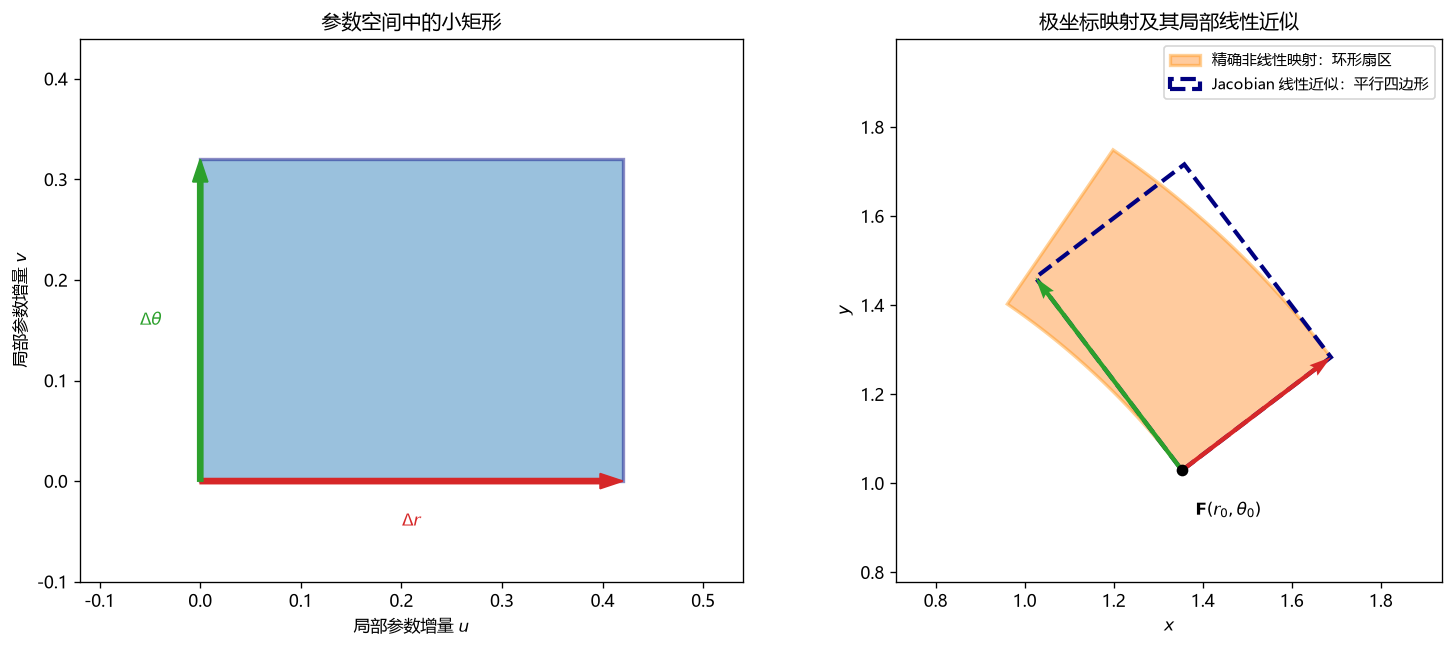

det(J0) = 1.700000
Jacobian 一阶面积 = 0.228480
有限环形扇区精确面积 = 0.256704
高阶差值 = 0.028224


In [8]:
# 基准点与参数增量
r0 = 1.7
theta0 = 0.65
delta_r = 0.42
delta_theta = 0.32

# 参数空间矩形的四个顶点，使用局部增量 (u, v)
parameter_corners = np.array([
    [0.0, 0.0],
    [delta_r, 0.0],
    [delta_r, delta_theta],
    [0.0, delta_theta],
])

# 极坐标非线性映射
def polar_map(radius, angle):
    return np.array([
        radius * np.cos(angle),
        radius * np.sin(angle),
    ])

base_point = polar_map(r0, theta0)

# 在 (r0, theta0) 处的 Jacobian
J0 = np.array([
    [np.cos(theta0), -r0 * np.sin(theta0)],
    [np.sin(theta0),  r0 * np.cos(theta0)],
])

# 局部线性映射得到的平行四边形顶点
linear_corners = base_point + parameter_corners @ J0.T

# 精确环形扇区边界
n_curve = 100

inner_angles = np.linspace(theta0, theta0 + delta_theta, n_curve)
outer_angles = np.linspace(theta0 + delta_theta, theta0, n_curve)

exact_boundary = np.vstack([
    np.column_stack([
        r0 * np.cos(inner_angles),
        r0 * np.sin(inner_angles),
    ]),
    np.column_stack([
        (r0 + delta_r) * np.cos(outer_angles),
        (r0 + delta_r) * np.sin(outer_angles),
    ]),
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ============================================================
# 左图：参数空间
# ============================================================
ax = axes[0]

param_rectangle = Polygon(
    parameter_corners,
    closed=True,
    facecolor="tab:blue",
    edgecolor="navy",
    alpha=0.45,
    linewidth=2,
)
ax.add_patch(param_rectangle)

ax.arrow(
    0,
    0,
    delta_r,
    0,
    width=0.005,
    length_includes_head=True,
    color="tab:red",
)
ax.arrow(
    0,
    0,
    0,
    delta_theta,
    width=0.005,
    length_includes_head=True,
    color="tab:green",
)

ax.text(delta_r / 2, -0.045, r"$\Delta r$", ha="center", color="tab:red")
ax.text(
    -0.06,
    delta_theta / 2,
    r"$\Delta\theta$",
    va="center",
    color="tab:green",
)

ax.set_xlim(-0.12, delta_r + 0.12)
ax.set_ylim(-0.10, delta_theta + 0.12)
ax.set_aspect("equal")
ax.set_xlabel(r"局部参数增量 $u$")
ax.set_ylabel(r"局部参数增量 $v$")
ax.set_title("参数空间中的小矩形")

# ============================================================
# 右图：精确映射与 Jacobian 线性化
# ============================================================
ax = axes[1]

exact_patch = Polygon(
    exact_boundary,
    closed=True,
    facecolor="tab:orange",
    edgecolor="darkorange",
    alpha=0.40,
    linewidth=2,
    label="精确非线性映射：环形扇区",
)
ax.add_patch(exact_patch)

linear_patch = Polygon(
    linear_corners,
    closed=True,
    facecolor="none",
    edgecolor="navy",
    linewidth=2.5,
    linestyle="--",
    label="Jacobian 线性近似：平行四边形",
)
ax.add_patch(linear_patch)

# Jacobian 两列对应的局部边向量
edge_r = J0 @ np.array([delta_r, 0.0])
edge_theta = J0 @ np.array([0.0, delta_theta])

ax.quiver(
    base_point[0],
    base_point[1],
    edge_r[0],
    edge_r[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:red",
    width=0.008,
)

ax.quiver(
    base_point[0],
    base_point[1],
    edge_theta[0],
    edge_theta[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:green",
    width=0.008,
)

ax.scatter(*base_point, color="black", zorder=5)
ax.text(
    base_point[0] + 0.03,
    base_point[1] - 0.10,
    r"$\mathbf{F}(r_0,\theta_0)$",
)

all_points = np.vstack([exact_boundary, linear_corners])
margin = 0.25

ax.set_xlim(all_points[:, 0].min() - margin, all_points[:, 0].max() + margin)
ax.set_ylim(all_points[:, 1].min() - margin, all_points[:, 1].max() + margin)
ax.set_aspect("equal")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title("极坐标映射及其局部线性近似")
ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

# 面积比较
jacobian_area = abs(np.linalg.det(J0)) * delta_r * delta_theta
exact_area = (
    0.5
    * ((r0 + delta_r) ** 2 - r0 ** 2)
    * delta_theta
)

print(f"det(J0) = {np.linalg.det(J0):.6f}")
print(f"Jacobian 一阶面积 = {jacobian_area:.6f}")
print(f"有限环形扇区精确面积 = {exact_area:.6f}")
print(f"高阶差值 = {exact_area - jacobian_area:.6f}")

## 3.3 三维直角、圆柱和球坐标体元

三种坐标系的局部边长分别为：

### 直角坐标

$$
dx,\qquad dy,\qquad dz.
$$

因此

$$
dV=dx\,dy\,dz.
$$

### 圆柱坐标

$$
dr,\qquad r\,d\theta,\qquad dz.
$$

因此

$$
dV=r\,dr\,d\theta\,dz.
$$

### 球坐标

$$
d\rho,\qquad
\rho\,d\varphi,\qquad
\rho\sin\varphi\,d\theta.
$$

因此

$$
dV=
\rho^2\sin\varphi
\,d\rho\,d\varphi\,d\theta.
$$

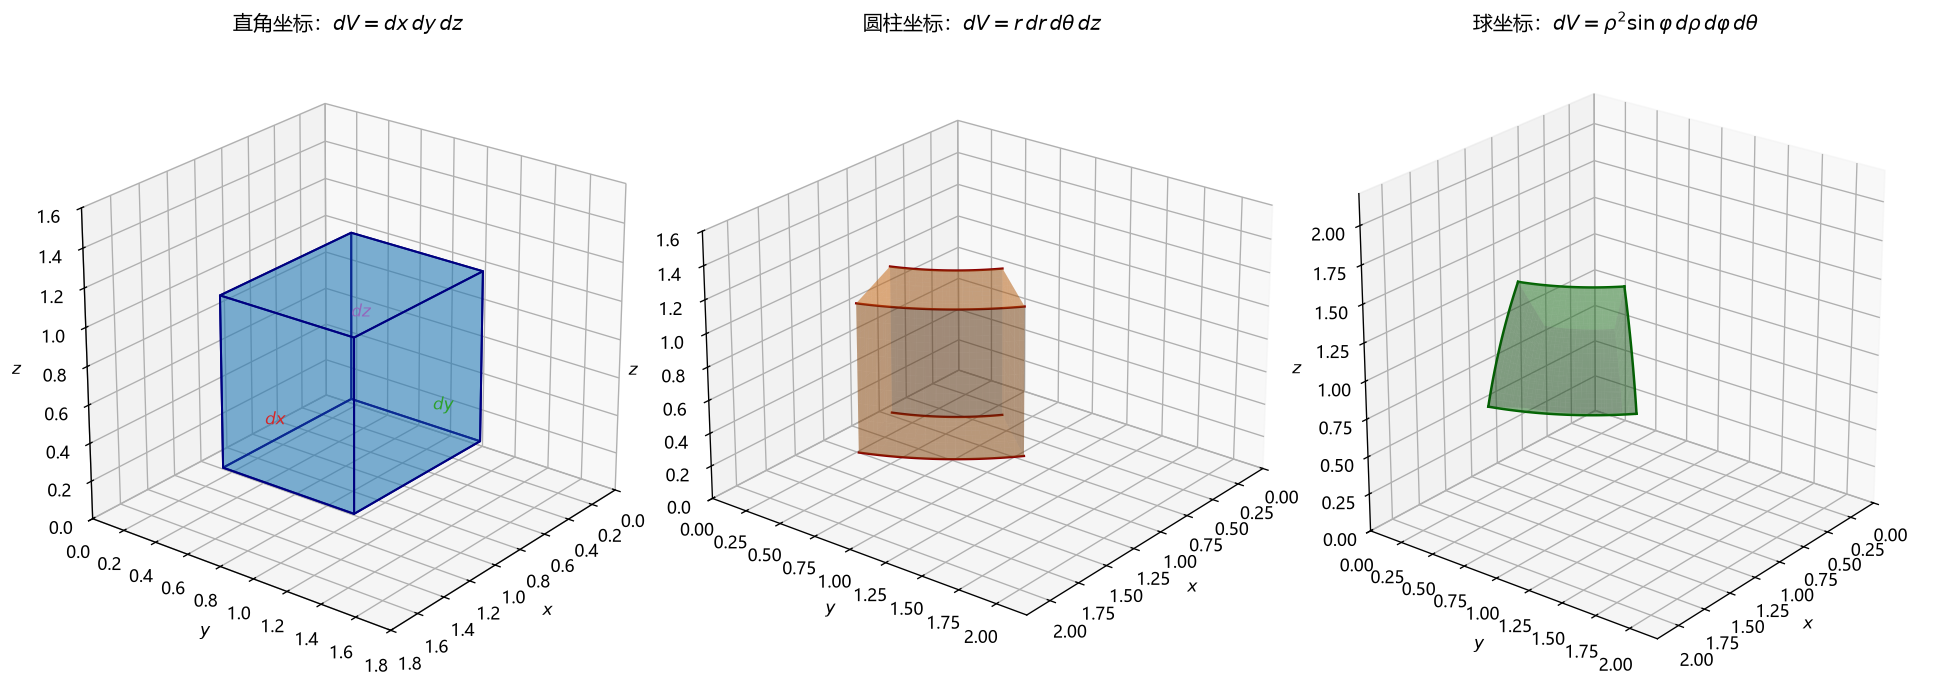

In [9]:
def set_3d_style(ax, title, limits):
    # 设置三维坐标轴显示样式
    ax.set_title(title, pad=14)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_zlabel(r"$z$")
    ax.set_xlim(limits[0])
    ax.set_ylim(limits[1])
    ax.set_zlim(limits[2])
    ax.set_box_aspect((
        limits[0][1] - limits[0][0],
        limits[1][1] - limits[1][0],
        limits[2][1] - limits[2][0],
    ))
    ax.view_init(elev=24, azim=38)


def add_cartesian_cell(ax):
    # 绘制直角坐标微小长方体
    x0, x1 = 0.3, 1.3
    y0, y1 = 0.4, 1.2
    z0, z1 = 0.2, 1.1

    vertices = np.array([
        [x0, y0, z0],
        [x1, y0, z0],
        [x1, y1, z0],
        [x0, y1, z0],
        [x0, y0, z1],
        [x1, y0, z1],
        [x1, y1, z1],
        [x0, y1, z1],
    ])

    faces = [
        [vertices[i] for i in [0, 1, 2, 3]],
        [vertices[i] for i in [4, 5, 6, 7]],
        [vertices[i] for i in [0, 1, 5, 4]],
        [vertices[i] for i in [1, 2, 6, 5]],
        [vertices[i] for i in [2, 3, 7, 6]],
        [vertices[i] for i in [3, 0, 4, 7]],
    ]

    collection = Poly3DCollection(
        faces,
        facecolors="tab:blue",
        edgecolors="navy",
        linewidths=1.2,
        alpha=0.35,
    )
    ax.add_collection3d(collection)

    ax.text((x0 + x1) / 2, y0 - 0.15, z0, r"$dx$", color="tab:red")
    ax.text(x0 - 0.15, (y0 + y1) / 2, z0, r"$dy$", color="tab:green")
    ax.text(x0, y0, (z0 + z1) / 2, r"$dz$", color="tab:purple")


def add_cylindrical_cell(ax):
    # 绘制圆柱坐标微小体元
    r0, r1 = 1.2, 1.75
    theta0, theta1 = 0.35, 0.88
    z0, z1 = 0.25, 1.15

    color = "tab:orange"

    # z = 常数的两个面
    rr, tt = np.meshgrid(
        np.linspace(r0, r1, 10),
        np.linspace(theta0, theta1, 18),
    )
    xx = rr * np.cos(tt)
    yy = rr * np.sin(tt)

    for z_fixed in [z0, z1]:
        zz = np.full_like(xx, z_fixed)
        ax.plot_surface(
            xx, yy, zz,
            color=color,
            alpha=0.30,
            edgecolor="none",
        )

    # r = 常数的两个圆柱面
    tt, zz = np.meshgrid(
        np.linspace(theta0, theta1, 18),
        np.linspace(z0, z1, 10),
    )

    for r_fixed in [r0, r1]:
        xx = r_fixed * np.cos(tt)
        yy = r_fixed * np.sin(tt)
        ax.plot_surface(
            xx, yy, zz,
            color=color,
            alpha=0.30,
            edgecolor="none",
        )

    # theta = 常数的两个径向平面
    rr, zz = np.meshgrid(
        np.linspace(r0, r1, 10),
        np.linspace(z0, z1, 10),
    )

    for theta_fixed in [theta0, theta1]:
        xx = rr * np.cos(theta_fixed)
        yy = rr * np.sin(theta_fixed)
        ax.plot_surface(
            xx, yy, zz,
            color=color,
            alpha=0.30,
            edgecolor="none",
        )

    # 绘制部分边界线
    for z_fixed in [z0, z1]:
        for r_fixed in [r0, r1]:
            angles = np.linspace(theta0, theta1, 80)
            ax.plot(
                r_fixed * np.cos(angles),
                r_fixed * np.sin(angles),
                z_fixed * np.ones_like(angles),
                color="darkred",
                lw=1.4,
            )


def spherical_xyz(rho_value, phi_value, theta_value):
    # 球坐标转直角坐标
    x = rho_value * np.sin(phi_value) * np.cos(theta_value)
    y = rho_value * np.sin(phi_value) * np.sin(theta_value)
    z = rho_value * np.cos(phi_value)
    return x, y, z


def add_spherical_cell(ax):
    # 绘制球坐标微小体元
    rho0, rho1 = 1.25, 1.85
    phi0, phi1 = 0.72, 1.15
    theta0, theta1 = 0.28, 0.82

    color = "tab:green"

    # rho = 常数的两个球面
    pp, tt = np.meshgrid(
        np.linspace(phi0, phi1, 18),
        np.linspace(theta0, theta1, 20),
    )

    for rho_fixed in [rho0, rho1]:
        xx, yy, zz = spherical_xyz(rho_fixed, pp, tt)
        ax.plot_surface(
            xx, yy, zz,
            color=color,
            alpha=0.30,
            edgecolor="none",
        )

    # phi = 常数的两个圆锥面
    rr, tt = np.meshgrid(
        np.linspace(rho0, rho1, 12),
        np.linspace(theta0, theta1, 20),
    )

    for phi_fixed in [phi0, phi1]:
        xx, yy, zz = spherical_xyz(rr, phi_fixed, tt)
        ax.plot_surface(
            xx, yy, zz,
            color=color,
            alpha=0.30,
            edgecolor="none",
        )

    # theta = 常数的两个半平面
    rr, pp = np.meshgrid(
        np.linspace(rho0, rho1, 12),
        np.linspace(phi0, phi1, 18),
    )

    for theta_fixed in [theta0, theta1]:
        xx, yy, zz = spherical_xyz(rr, pp, theta_fixed)
        ax.plot_surface(
            xx, yy, zz,
            color=color,
            alpha=0.30,
            edgecolor="none",
        )

    # 外球面上的部分边界线
    angles_phi = np.linspace(phi0, phi1, 100)
    angles_theta = np.linspace(theta0, theta1, 100)

    for theta_fixed in [theta0, theta1]:
        xx, yy, zz = spherical_xyz(rho1, angles_phi, theta_fixed)
        ax.plot(xx, yy, zz, color="darkgreen", lw=1.5)

    for phi_fixed in [phi0, phi1]:
        xx, yy, zz = spherical_xyz(rho1, phi_fixed, angles_theta)
        ax.plot(xx, yy, zz, color="darkgreen", lw=1.5)


fig = plt.figure(figsize=(16, 5.5))

# 直角坐标体元
ax1 = fig.add_subplot(131, projection="3d")
add_cartesian_cell(ax1)
set_3d_style(
    ax1,
    r"直角坐标：$dV=dx\,dy\,dz$",
    ((0, 1.8), (0, 1.8), (0, 1.6)),
)

# 圆柱坐标体元
ax2 = fig.add_subplot(132, projection="3d")
add_cylindrical_cell(ax2)
set_3d_style(
    ax2,
    r"圆柱坐标：$dV=r\,dr\,d\theta\,dz$",
    ((0, 2.2), (0, 2.2), (0, 1.6)),
)

# 球坐标体元
ax3 = fig.add_subplot(133, projection="3d")
add_spherical_cell(ax3)
set_3d_style(
    ax3,
    r"球坐标：$dV=\rho^2\sin\varphi\,d\rho\,d\varphi\,d\theta$",
    ((0, 2.2), (0, 2.2), (0, 2.2)),
)

plt.tight_layout()
plt.show()

## 3.4 三维坐标曲面的面积元

### 圆柱面 $r=R$

参数化为

$$
\mathbf S(\theta,z)
=
\begin{pmatrix}
R\cos\theta\\
R\sin\theta\\
z
\end{pmatrix}.
$$

两个切向量为

$$
\mathbf S_\theta
=
\begin{pmatrix}
-R\sin\theta\\
R\cos\theta\\
0
\end{pmatrix},
\qquad
\mathbf S_z
=
\begin{pmatrix}
0\\0\\1
\end{pmatrix}.
$$

其长度分别为

$$
R,\qquad1.
$$

二者相互垂直，所以

$$
dS=R\,d\theta\,dz.
$$

### 球面 $\rho=R$

参数化为

$$
\mathbf S(\varphi,\theta)
=
\begin{pmatrix}
R\sin\varphi\cos\theta\\
R\sin\varphi\sin\theta\\
R\cos\varphi
\end{pmatrix}.
$$

两个切向方向的局部长度分别为

$$
R\,d\varphi,
\qquad
R\sin\varphi\,d\theta.
$$

因此

$$
dS=R^2\sin\varphi\,d\varphi\,d\theta.
$$

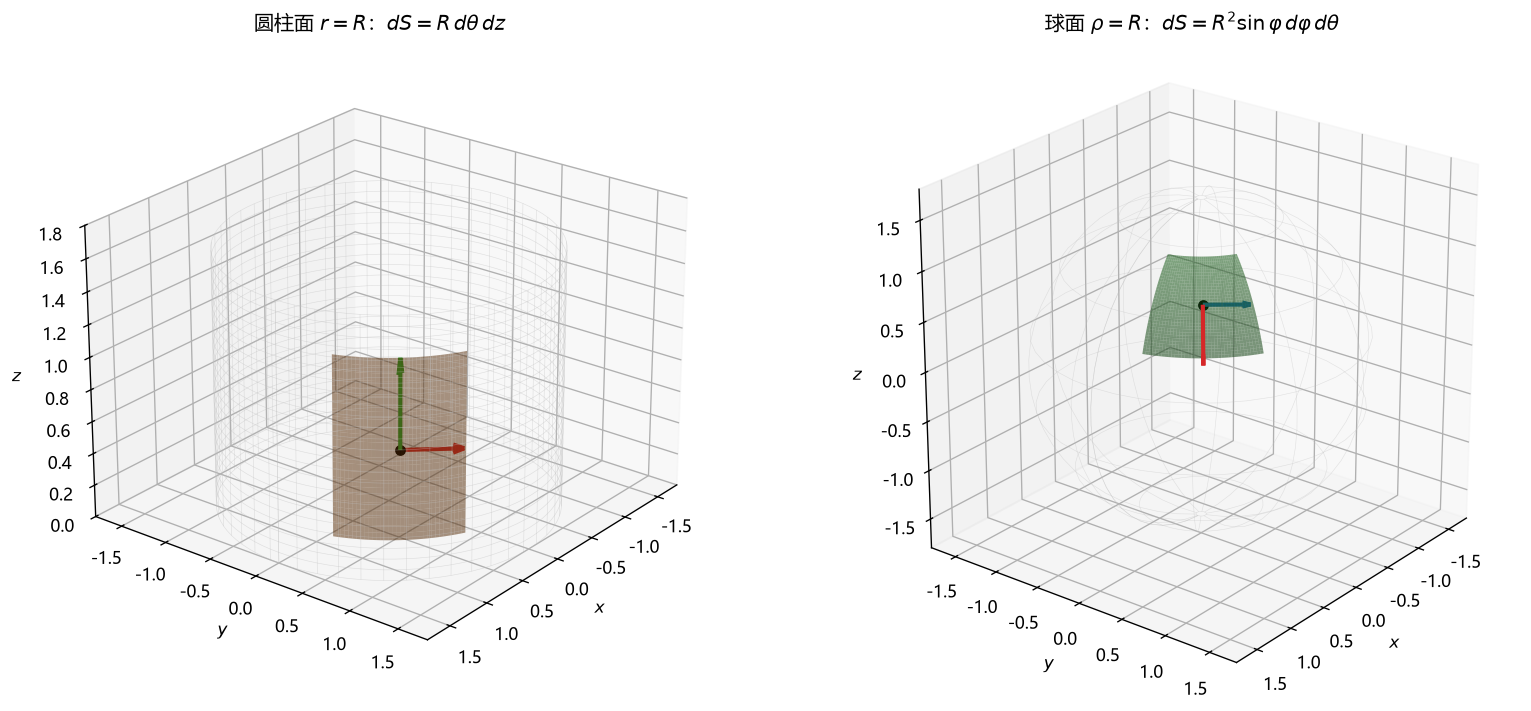

In [10]:
fig = plt.figure(figsize=(14, 6))

# ============================================================
# 左图：圆柱面面积元
# ============================================================
ax1 = fig.add_subplot(121, projection="3d")

R_cyl = 1.5
theta0, theta1 = 0.35, 1.10
z0, z1 = 0.25, 1.35

theta_grid, z_grid = np.meshgrid(
    np.linspace(theta0, theta1, 35),
    np.linspace(z0, z1, 25),
)

x_grid = R_cyl * np.cos(theta_grid)
y_grid = R_cyl * np.sin(theta_grid)

ax1.plot_surface(
    x_grid,
    y_grid,
    z_grid,
    color="tab:orange",
    alpha=0.50,
    edgecolor="none",
)

# 参考圆柱曲面
theta_full, z_full = np.meshgrid(
    np.linspace(0, 2 * np.pi, 100),
    np.linspace(0, 1.6, 25),
)

ax1.plot_wireframe(
    R_cyl * np.cos(theta_full),
    R_cyl * np.sin(theta_full),
    z_full,
    color="0.75",
    linewidth=0.35,
    alpha=0.45,
)

# 中心点及切向量
theta_c = (theta0 + theta1) / 2
z_c = (z0 + z1) / 2

point_cyl = np.array([
    R_cyl * np.cos(theta_c),
    R_cyl * np.sin(theta_c),
    z_c,
])

tangent_theta = np.array([
    -R_cyl * np.sin(theta_c),
    R_cyl * np.cos(theta_c),
    0,
])

tangent_z = np.array([0, 0, 1])

arrow_scale_theta = 0.35
arrow_scale_z = 0.55

ax1.quiver(
    *point_cyl,
    *(arrow_scale_theta * tangent_theta),
    color="tab:red",
    linewidth=2.5,
    arrow_length_ratio=0.18,
)

ax1.quiver(
    *point_cyl,
    *(arrow_scale_z * tangent_z),
    color="tab:green",
    linewidth=2.5,
    arrow_length_ratio=0.18,
)

ax1.scatter(*point_cyl, color="black", s=30)

ax1.set_title(r"圆柱面 $r=R$：$dS=R\,d\theta\,dz$")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$y$")
ax1.set_zlabel(r"$z$")
ax1.set_xlim(-1.8, 1.8)
ax1.set_ylim(-1.8, 1.8)
ax1.set_zlim(0, 1.8)
ax1.set_box_aspect((1, 1, 0.75))
ax1.view_init(elev=24, azim=38)

# ============================================================
# 右图：球面面积元
# ============================================================
ax2 = fig.add_subplot(122, projection="3d")

R_sph = 1.6
phi0, phi1 = 0.55, 1.15
theta0, theta1 = 0.30, 1.05

phi_grid, theta_grid = np.meshgrid(
    np.linspace(phi0, phi1, 35),
    np.linspace(theta0, theta1, 38),
)

x_grid, y_grid, z_grid = spherical_xyz(
    R_sph,
    phi_grid,
    theta_grid,
)

ax2.plot_surface(
    x_grid,
    y_grid,
    z_grid,
    color="tab:green",
    alpha=0.55,
    edgecolor="none",
)

# 参考球面线框
phi_full, theta_full = np.meshgrid(
    np.linspace(0.03, np.pi - 0.03, 28),
    np.linspace(0, 2 * np.pi, 42),
)

x_full, y_full, z_full = spherical_xyz(
    R_sph,
    phi_full,
    theta_full,
)

ax2.plot_wireframe(
    x_full,
    y_full,
    z_full,
    rstride=4,
    cstride=4,
    color="0.75",
    linewidth=0.35,
    alpha=0.40,
)

# 球面面积元中心点与切向量
phi_c = (phi0 + phi1) / 2
theta_c = (theta0 + theta1) / 2

point_sph = np.array(
    spherical_xyz(R_sph, phi_c, theta_c)
)

tangent_phi = np.array([
    R_sph * np.cos(phi_c) * np.cos(theta_c),
    R_sph * np.cos(phi_c) * np.sin(theta_c),
    -R_sph * np.sin(phi_c),
])

tangent_theta = np.array([
    -R_sph * np.sin(phi_c) * np.sin(theta_c),
    R_sph * np.sin(phi_c) * np.cos(theta_c),
    0,
])

arrow_scale_phi = 0.35
arrow_scale_theta = 0.35

ax2.quiver(
    *point_sph,
    *(arrow_scale_phi * tangent_phi),
    color="tab:red",
    linewidth=2.5,
    arrow_length_ratio=0.18,
)

ax2.quiver(
    *point_sph,
    *(arrow_scale_theta * tangent_theta),
    color="tab:blue",
    linewidth=2.5,
    arrow_length_ratio=0.18,
)

ax2.scatter(*point_sph, color="black", s=30)

ax2.set_title(
    r"球面 $\rho=R$："
    r"$dS=R^2\sin\varphi\,d\varphi\,d\theta$"
)
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$y$")
ax2.set_zlabel(r"$z$")
ax2.set_xlim(-1.8, 1.8)
ax2.set_ylim(-1.8, 1.8)
ax2.set_zlim(-1.8, 1.8)
ax2.set_box_aspect((1, 1, 1))
ax2.view_init(elev=24, azim=38)

plt.tight_layout()
plt.show()

# 4. 使用积分检验微元公式

下面用几个经典结果检验前面得到的微元。

## 4.1 圆盘面积

半径为 $R$ 的圆盘：

$$
0\leq r\leq R,
\qquad
0\leq\theta<2\pi.
$$

利用极坐标面积元：

$$
A
=
\int_0^{2\pi}\int_0^R
r\,dr\,d\theta
=
\pi R^2.
$$

## 4.2 圆柱体积

半径为 $R$、高度为 $H$ 的圆柱：

$$
V
=
\int_0^H
\int_0^{2\pi}
\int_0^R
r\,dr\,d\theta\,dz
=
\pi R^2H.
$$

## 4.3 球体积

半径为 $R$ 的球：

$$
V
=
\int_0^{2\pi}
\int_0^\pi
\int_0^R
\rho^2\sin\varphi
\,d\rho\,d\varphi\,d\theta
=
\frac43\pi R^3.
$$

## 4.4 球面面积

半径为 $R$ 的球面：

$$
A
=
\int_0^{2\pi}
\int_0^\pi
R^2\sin\varphi
\,d\varphi\,d\theta
=
4\pi R^2.
$$

In [ ]:
R, H = sp.symbols("R H", positive=True, real=True)
r, theta, z = sp.symbols("r theta z", real=True)
rho, phi = sp.symbols("rho phi", real=True)

# 圆盘面积
disk_area = sp.integrate(
    r,
    (r, 0, R),
    (theta, 0, 2 * sp.pi),
)

# 圆柱体积
cylinder_volume = sp.integrate(
    r,
    (r, 0, R),
    (theta, 0, 2 * sp.pi),
    (z, 0, H),
)

# 球体积
sphere_volume = sp.integrate(
    rho**2 * sp.sin(phi),
    (rho, 0, R),
    (phi, 0, sp.pi),
    (theta, 0, 2 * sp.pi),
)

# 球面面积
sphere_area = sp.integrate(
    R**2 * sp.sin(phi),
    (phi, 0, sp.pi),
    (theta, 0, 2 * sp.pi),
)

results = [
    ("圆盘面积", disk_area),
    ("圆柱体积", cylinder_volume),
    ("球体积", sphere_volume),
    ("球面面积", sphere_area),
]

for name, result in results:
    print(f"{name}:")
    display(sp.simplify(result))

## 4.5 数值积分验证

使用简单的中点求积，分别估计：

- 单位圆盘面积；
- 单位球体积；
- 单位球面面积。

理论结果分别是

$$
\pi,\qquad
\frac{4\pi}{3},\qquad
4\pi.
$$

In [ ]:
def midpoint_grid(a, b, n):
    # 返回区间 [a,b] 的中点网格和网格宽度
    edges = np.linspace(a, b, n + 1)
    midpoints = 0.5 * (edges[:-1] + edges[1:])
    delta = (b - a) / n
    return midpoints, delta


# ------------------------------------------------------------
# 1. 单位圆盘面积
# ------------------------------------------------------------
r_mid, dr = midpoint_grid(0.0, 1.0, 500)
theta_mid, dtheta = midpoint_grid(0.0, 2 * np.pi, 600)

rr, tt = np.meshgrid(r_mid, theta_mid, indexing="ij")
disk_area_numeric = np.sum(rr) * dr * dtheta

# ------------------------------------------------------------
# 2. 单位球体积
# ------------------------------------------------------------
rho_mid, drho = midpoint_grid(0.0, 1.0, 180)
phi_mid, dphi = midpoint_grid(0.0, np.pi, 220)
theta_mid, dtheta = midpoint_grid(0.0, 2 * np.pi, 260)

rrho, pphi, ttheta = np.meshgrid(
    rho_mid,
    phi_mid,
    theta_mid,
    indexing="ij",
)

sphere_volume_numeric = np.sum(
    rrho**2 * np.sin(pphi)
) * drho * dphi * dtheta

# ------------------------------------------------------------
# 3. 单位球面面积
# ------------------------------------------------------------
phi_mid, dphi = midpoint_grid(0.0, np.pi, 600)
theta_mid, dtheta = midpoint_grid(0.0, 2 * np.pi, 700)

pphi, ttheta = np.meshgrid(
    phi_mid,
    theta_mid,
    indexing="ij",
)

sphere_area_numeric = np.sum(
    np.sin(pphi)
) * dphi * dtheta

print("单位圆盘面积")
print(f"  数值结果：{disk_area_numeric:.10f}")
print(f"  理论结果：{np.pi:.10f}")
print()

print("单位球体积")
print(f"  数值结果：{sphere_volume_numeric:.10f}")
print(f"  理论结果：{4 * np.pi / 3:.10f}")
print()

print("单位球面面积")
print(f"  数值结果：{sphere_area_numeric:.10f}")
print(f"  理论结果：{4 * np.pi:.10f}")

# 5. 总结

## 5.1 二维面积元

### 直角坐标

$$
\boxed{dA=dx\,dy}
$$

### 极坐标

$$
\boxed{dA=r\,dr\,d\theta}
$$

其中因子 $r$ 来自角向弧长

$$
r\,d\theta,
$$

也等于极坐标变换的 Jacobian 行列式绝对值。

---

## 5.2 三维体积元

### 直角坐标

$$
\boxed{dV=dx\,dy\,dz}
$$

### 圆柱坐标

$$
\boxed{dV=r\,dr\,d\theta\,dz}
$$

### 球坐标

$$
\boxed{
dV=\rho^2\sin\varphi
\,d\rho\,d\varphi\,d\theta
}
$$

---

## 5.3 三维坐标曲面的面积元

### 直角坐标

$$
\boxed{x=\text{常数}:\ dS=dy\,dz}
$$

$$
\boxed{y=\text{常数}:\ dS=dx\,dz}
$$

$$
\boxed{z=\text{常数}:\ dS=dx\,dy}
$$

### 圆柱坐标

$$
\boxed{r=\text{常数}:\ dS=r\,d\theta\,dz}
$$

$$
\boxed{\theta=\text{常数}:\ dS=dr\,dz}
$$

$$
\boxed{z=\text{常数}:\ dS=r\,dr\,d\theta}
$$

### 球坐标

$$
\boxed{
\rho=\text{常数}:\ 
dS=\rho^2\sin\varphi\,d\varphi\,d\theta
}
$$

$$
\boxed{
\varphi=\text{常数}:\ 
dS=\rho\sin\varphi\,d\rho\,d\theta
}
$$

$$
\boxed{
\theta=\text{常数}:\ 
dS=\rho\,d\rho\,d\varphi
}
$$

---

## 5.4 Jacobian 的统一理解

### 二维变量变换

$$
\boxed{
dA=
\left|\det J\right|
\,du\,dv
}
$$

其中 $|\det J|$ 是局部面积伸缩倍数。

### 三维变量变换

$$
\boxed{
dV=
\left|\det J\right|
\,dq_1\,dq_2\,dq_3
}
$$

其中 $|\det J|$ 是局部体积伸缩倍数。

### 三维参数曲面

$$
\boxed{
dS=
\|\mathbf S_u\times\mathbf S_v\|
\,du\,dv
}
$$

或者

$$
\boxed{
dS=
\sqrt{
\det\left[
(D\mathbf S)^T(D\mathbf S)
\right]
}
\,du\,dv
}
$$

---

## 5.5 坐标奇点

以下位置 Jacobian 会变为零：

- 极坐标和圆柱坐标中的 $r=0$；
- 球坐标中的 $\rho=0$；
- 球坐标中的 $\varphi=0,\pi$。

这通常是**坐标表示退化**，并不表示空间本身存在几何奇点。

例如在球坐标的南北极，所有方位角 $\theta$ 都表示同一个点，因此方位角方向的局部长度

$$
\rho\sin\varphi\,d\theta
$$

在极点处变为零。

---

## 5.6 核心记忆方法

不必只机械记忆公式，可以记住各坐标方向对应的实际局部边长。

### 极坐标

$$
dr,\qquad r\,d\theta.
$$

### 圆柱坐标

$$
dr,\qquad r\,d\theta,\qquad dz.
$$

### 球坐标

$$
d\rho,\qquad
\rho\,d\varphi,\qquad
\rho\sin\varphi\,d\theta.
$$

- 在二维中，将两个局部边长相乘得到面积元；
- 在三维中，将三个局部边长相乘得到体积元；
- 固定一个坐标后，将剩余两个切向边长相乘得到坐标曲面的面积元。